# Multi-Hypothesis GPS Emissions Pipeline Orchestrator

This notebook runs the production hierarchical hybrid modal classifier. Selection is controlled only by `config.MODAL_CLASSIFIER`.

---

## Phase 0: Environment Setup & Module Imports

We load Jupyter's autoreload extension to dynamically capture edits in the source `.py` modules. We then append the root folder to `sys.path` and import our modular architecture components.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import time
import pickle
import warnings
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from shapely import wkt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Set project and package paths
NOTEBOOK_DIR = Path.cwd()
sys.path.append(os.path.abspath(NOTEBOOK_DIR))

import src.config as config
from src.segmentation import preprocess_gps_data, assign_trips, apply_spatial_filter
from src.modal_classification import calcular_cercania_infraestructura, PriorModeClassifier, create_modal_evaluator
from src.routing import get_candidates_vectorized, complete_route, RouteHypothesisEvaluator
from src.emissions import calculate_emissions

print("Modules imported successfully!")

Modules imported successfully!


## Phase 1: Load Network Graphs & Infrastructure Data

We load base NetworkX graphs, optimized iGraph indices from cache, and geographic transit layers (bus and subway) and project them to the metric coordinate system UTM 14N (`EPSG:32614`).

In [2]:
print("Loading road networks (NetworkX and iGraph)... ")
start_time = time.time()

with open(config.FILE_GRAFO, 'rb') as f:
    G_drive = pickle.load(f)
with open(config.FILE_GRAFO_WALK, 'rb') as f:
    G_walk = pickle.load(f)

with open(config.FILE_CACHE_IG_DRIVE, 'rb') as f:
    ig_drive, map_drive = pickle.load(f)
with open(config.FILE_CACHE_IG_WALK, 'rb') as f:
    ig_walk, map_walk = pickle.load(f)

edges_drive = gpd.read_parquet(config.FILE_CACHE_EDGES_DRIVE)
edges_walk = gpd.read_parquet(config.FILE_CACHE_EDGES_WALK)

print(f"Road networks loaded in {time.time() - start_time:.2f} seconds.")

print("Loading transit infrastructure routes...")
bus_routes = gpd.read_file(config.FILE_BUS).to_crs("EPSG:32614")
subway_df = pd.read_csv(config.FILE_METRO)

if 'geometry' in subway_df.columns:
    subway_df['geometry'] = subway_df['geometry'].apply(wkt.loads)
    subway_routes = gpd.GeoDataFrame(subway_df, geometry='geometry', crs="EPSG:4326")
elif 'WKT' in subway_df.columns:
    subway_df['geometry'] = subway_df['WKT'].apply(wkt.loads)
    subway_routes = gpd.GeoDataFrame(subway_df, geometry='geometry', crs="EPSG:4326")
elif 'lat' in subway_df.columns and 'lon' in subway_df.columns:
    subway_routes = gpd.GeoDataFrame(subway_df, geometry=gpd.points_from_xy(subway_df.lon, subway_df.lat), crs="EPSG:4326")
else:
    raise ValueError("Subway route file format is unsupported.")

subway_routes = subway_routes.to_crs("EPSG:32614")
subway_routes_proj = subway_routes.copy()

print("All infrastructure datasets loaded and projected!")

Loading road networks (NetworkX and iGraph)... 
Road networks loaded in 26.69 seconds.
Loading transit infrastructure routes...
All infrastructure datasets loaded and projected!


## Phase 2: Load and Preprocess GPS Data

We load the GPS parquet dataset, apply Monterey geofencing, temporal downsampling, and edge-shielding filters. Due to local resource constraints, we restrict this test run to a sample of 3 users.

In [3]:
df_sample, usuarios = preprocess_gps_data(config.FILE_GPS_ORIGINAL, num_users=4)
print(f"Sample user caids to process: {usuarios}")

Cargando y preprocesando datos GPS crudos...
 -> Registros en muestra temporal: 62,635
Sample user caids to process: ['d2485b5d260a817ed896def3ce97eb29a00853816ae248cef036d1b9f4dfdb66', '871b29f8066eb2d6e5ad094a91e0f8eb90d92da9ea5589c37c1c527b99cfb5ef', 'c5ce4dc8dafd1480fcb8b61645ec01dbb96fb12b34635285b5f8fcebc57c4858', '7e753acacae7e133a4a09a8a07ffd2fd64d9c4a95284eae34f681ecde3001904']


## Phase 3: Multi-Hypothesis Day Orchestration Wrapper

We define the `process_day_wrapper_multi_hypothesis` function to segment, classify, route, and evaluate the trajectories day-by-day. It routes each active trip under multiple candidate mode hypotheses and selects the top-matching route based on the physical and network metrics.

In [4]:
def process_day_wrapper_multi_hypothesis(id_usuario, fecha, df_dia,
                                        G_drive, G_walk, ig_drive, ig_walk, 
                                        map_drive, map_walk, edges_drive, edges_walk, 
                                        subway_routes, bus_routes, subway_routes_proj):
    """
    Processes one user-day using the multi-hypothesis coarse-to-fine routing paradigm.
    """
    if df_dia.empty:
        return pd.DataFrame()

    # Step 1: Temporal trip segmentation
    df_dia = apply_spatial_filter(df_dia, min_dist_m=15.0)
    df_dia = assign_trips(df_dia)
    
    # Step 2: Compute initial infrastructure proximity metrics
    df_dia = calcular_cercania_infraestructura(df_dia, subway_routes, bus_routes)
    
    # Step 3: Candidate edge mapping (spatial search)
    col_lat = 'lat_ruteo' if 'lat_ruteo' in df_dia.columns else 'latitude'
    col_lon = 'lon_ruteo' if 'lon_ruteo' in df_dia.columns else 'longitude'
    gdf_dia = gpd.GeoDataFrame(df_dia, geometry=gpd.points_from_xy(df_dia[col_lon], df_dia[col_lat]), crs="EPSG:4326")
    
    graph_crs = edges_drive.crs
    gdf_dia_proj = gdf_dia.to_crs(graph_crs)
    
    df_dia['drive_ids'], df_dia['drive_dists'] = get_candidates_vectorized(edges_drive, gdf_dia_proj, buffer_m=150)
    df_dia['walk_ids'], df_dia['walk_dists'] = get_candidates_vectorized(edges_walk, gdf_dia_proj, buffer_m=50)
    
    prior_classifier = PriorModeClassifier()
    evaluator = RouteHypothesisEvaluator(G_drive, G_walk, ig_drive, ig_walk, map_drive, map_walk, subway_routes_proj)
    scorer = create_modal_evaluator(config.MODAL_CLASSIFIER)
    
    all_routed_trips = []
    
    # Process trip by trip
    for trip_id, df_trip in df_dia.groupby('trip'):
        if trip_id <= 0:
            # Process stationary/stop intervals
            df_stop = df_trip.copy()
            df_stop['modo_transporte'] = 'Parada'
            
            df_stop_routed = pd.DataFrame({
                'caid': id_usuario, 'trip': trip_id,
                'latitude': df_stop['latitude'], 'longitude': df_stop['longitude'],
                'Speed [km/h]': 0.0, 'local_timestamp': df_stop['local_timestamp'],
                'start_node': 'N/A', 'end_node': 'N/A', 'osmid': 'N/A', 
                'highway': 'parada_inactiva',
                'geometry': [f'POINT ({lon} {lat})' for lon, lat in zip(df_stop['longitude'], df_stop['latitude'])],
                'distance_m': 0.0, 'modo_transporte': 'Parada',
                'ruteo_fallido': False, 'corregido_espacialmente': False, 
                'flag_auditoria': 'Parada_Inactiva'
            })
            all_routed_trips.append(df_stop_routed)
            continue
            
        near_subway = df_trip['near_subway_line']
        near_bus = df_trip['near_bus_route']
        
        # Predict prior mode candidates using raw GPS metrics (pruning impossible hypotheses)
        candidates = prior_classifier.prune_impossible_hypotheses(df_trip, near_subway, near_bus)
        
        # Route candidate hypotheses (topological & physical routing)
        hypotheses = evaluator.evaluate(id_usuario, df_trip, candidates)
        
        # Select final mode through the single configuration-driven factory
        best_mode, best_df, best_prob, diagnostic_probs = scorer.select_final_mode(hypotheses, subway_routes, bus_routes)
        
        if best_df is not None:
            all_routed_trips.append(best_df)
            
    if len(all_routed_trips) > 0:
        return pd.concat(all_routed_trips, ignore_index=True)
    else:
        return pd.DataFrame()

## Phase 4: Run the Orchestrated Map-Matching Pipeline in Parallel

We group the GPS data by user and date, and execute the multi-hypothesis ruteo pipeline in parallel using `joblib` and `tqdm` for live progress tracking. Demo boundaries (e.g. limiting users and days) can be modified or disabled by setting them to `None`.

In [5]:
from joblib import Parallel, delayed

# Demostración / límites de recursos (poner None para procesar todo el conjunto)
LIMIT_USERS = None
LIMIT_DAYS_PER_USER = None

# --- PREPARACIÓN DE TAREAS ---
df_sample['date'] = df_sample['local_timestamp'].dt.date
usuarios_unicos = df_sample['caid'].unique()
if LIMIT_USERS:
    usuarios_unicos = usuarios_unicos[:LIMIT_USERS]

grupos_tareas = []
for user in usuarios_unicos:
    df_user = df_sample[df_sample['caid'] == user].copy()
    dias_usuario = df_user['date'].unique()
    if LIMIT_DAYS_PER_USER:
        dias_usuario = sorted(dias_usuario)[:LIMIT_DAYS_PER_USER]
    
    for dia in dias_usuario:
        df_dia = df_user[df_user['date'] == dia].copy()
        grupos_tareas.append(((user, dia), df_dia))

total_tareas = len(grupos_tareas)
print(f"Total de tareas (Usuario-Día) a procesar: {total_tareas}")
print("Iniciando procesamiento paralelo...")
start_proc = time.time()

resultados_multi = Parallel(n_jobs=3, backend="threading")(
    delayed(process_day_wrapper_multi_hypothesis)(
        id_usuario, fecha_dia, grupo_df,
        G_drive, G_walk, ig_drive, ig_walk, map_drive, map_walk,
        edges_drive, edges_walk, subway_routes, bus_routes, subway_routes_proj
    ) for (id_usuario, fecha_dia), grupo_df in tqdm(grupos_tareas, desc="Procesando Pipeline")
)

t_multi = time.time() - start_proc
print(f"\nParallel map-matching routing finished in {t_multi:.2f} seconds.")

Total de tareas (Usuario-Día) a procesar: 162
Iniciando procesamiento paralelo...


Procesando Pipeline:   0%|          | 0/162 [00:00<?, ?it/s]


Parallel map-matching routing finished in 503.82 seconds.


## Phase 5: Cruce with MOVES Emissions Inventory

We aggregate the routed trajectories, verify type consistency to prevent PyArrow serialization errors (ArrowTypeError), and execute the emissions module to calculate criteria pollutant levels.

In [6]:
resultados_limpios = [r for r in resultados_multi if r is not None and not r.empty]
if len(resultados_limpios) > 0:
    df_final_multi = pd.concat(resultados_limpios, ignore_index=True)
    print(f"Generated routed points: {len(df_final_multi):,}")
    
    # Cast potential object columns with mixed types to string for pyarrow parquet serialization
    for col in ['start_node', 'end_node', 'osmid', 'highway']:
        if col in df_final_multi.columns:
            df_final_multi[col] = df_final_multi[col].astype(str)
            
    # Calculate emissions
    df_final = calculate_emissions(df_final_multi, config.FILE_MOVES)
else:
    print("Error: No routing outputs were generated!")
    df_final = pd.DataFrame()

Generated routed points: 83,755
Iniciando Módulo 3: Cálculo de emisiones...
Módulo 3 completado exitosamente.


## Phase 6: Post-Processing & Output Generation

We print diagnostic summaries of the transportation modes and emissions inventory, and save the final outputs as a parquet database and Kepler.gl CSV.

In [7]:
if not df_final.empty:
    print("=" * 60)
    print("DIAGNOSTIC REPORT: EMISSIONS & MODES")
    print("=" * 60)
    
    print("\n▶ 1. Mode Distribution:")
    print(df_final['modo_transporte'].value_counts())
    
    ruteo_exito = (~df_final['ruteo_fallido']).mean() * 100
    print(f"\n▶ 2. Map-Matching Success Rate: {ruteo_exito:.2f}%")
    
    print("\n▶ 3. Pollutant Emissions Inventory (Total Mass):")
    POLLUTANTS_noeqiv = ['CO', 'CO2', 'HC', 'NOx', 'PM10', 'PM25']
    for p in POLLUTANTS_noeqiv:
        total_g = df_final[f"Total_{p}_g"].sum()
        print(f"   - {p}: {total_g:,.2f} g")
        
    # Create outputs folder dynamically
    config.FINAL_DIR.mkdir(parents=True, exist_ok=True)
    
    # Save parquet
    final_parquet_path = config.FINAL_DIR / "Resultados_Datos_Emisiones_GPS_VERASET.parquet"
    df_final.to_parquet(final_parquet_path)
    print(f"\nSaved final emissions Parquet to: {final_parquet_path}")
    
    # Save Kepler CSV
    final_csv_path = config.FINAL_DIR / "Resultados_Mapa_Emisiones_GPS_Kepler_VERASET.csv"
    columnas_mantener = [
        'caid', 'trip', 'fecha_kepler', 'Speed [km/h]', 'osmid', 'highway',
        'geometry', 'distance_m', 'modo_transporte', 
        'Densidad_CO_g_km', 'Total_CO_g', 'Densidad_CO2_g_km', 'Total_CO2_g',
        'Densidad_CO2_Equiv_g_km', 'Total_CO2_Equiv_g', 'Densidad_HC_g_km',
        'Total_HC_g', 'Densidad_NOx_g_km', 'Total_NOx_g', 'Densidad_PM10_g_km',
        'Total_PM10_g', 'Densidad_PM25_g_km', 'Total_PM25_g', 'latitude', 'longitude'
    ]
    columnas_presentes = [c for c in columnas_mantener if c in df_final.columns]
    df_mapa = df_final[columnas_presentes].dropna(subset=['geometry'])
    df_mapa.to_csv(final_csv_path, index=False)
    print(f"Saved Kepler.gl CSV map to: {final_csv_path}")
    print("=" * 60)
else:
    print("Pipeline output is empty, skipping export.")

DIAGNOSTIC REPORT: EMISSIONS & MODES

▶ 1. Mode Distribution:
modo_transporte
Carro      53762
Parada     26529
Caminar     2964
Bus          483
Metro         17
Name: count, dtype: int64

▶ 2. Map-Matching Success Rate: 92.49%

▶ 3. Pollutant Emissions Inventory (Total Mass):
   - CO: 61,294.72 g
   - CO2: 1,711,502.99 g
   - HC: 1,166.67 g
   - NOx: 9,796.37 g
   - PM10: 203.22 g
   - PM25: 179.33 g

Saved final emissions Parquet to: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0\Outputs\Final Outputs\Resultados_Datos_Emisiones_GPS_VERASET.parquet
Saved Kepler.gl CSV map to: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0\Outputs\Final Outputs\Resultados_Mapa_Emisiones_GPS_Kepler_VERASET.csv


## Phase 7: Sanity Checks & Quality Metrics Visualization

We perform a macro trip-level analysis (auditing sinuosity, travel distances, and data loss rates due to amnesia/lookahead skips) and evaluate the emissions inventory mapping quality.

AUDITORÍA DE VIAJES CONSOLIDADA: 159 viajes únicos


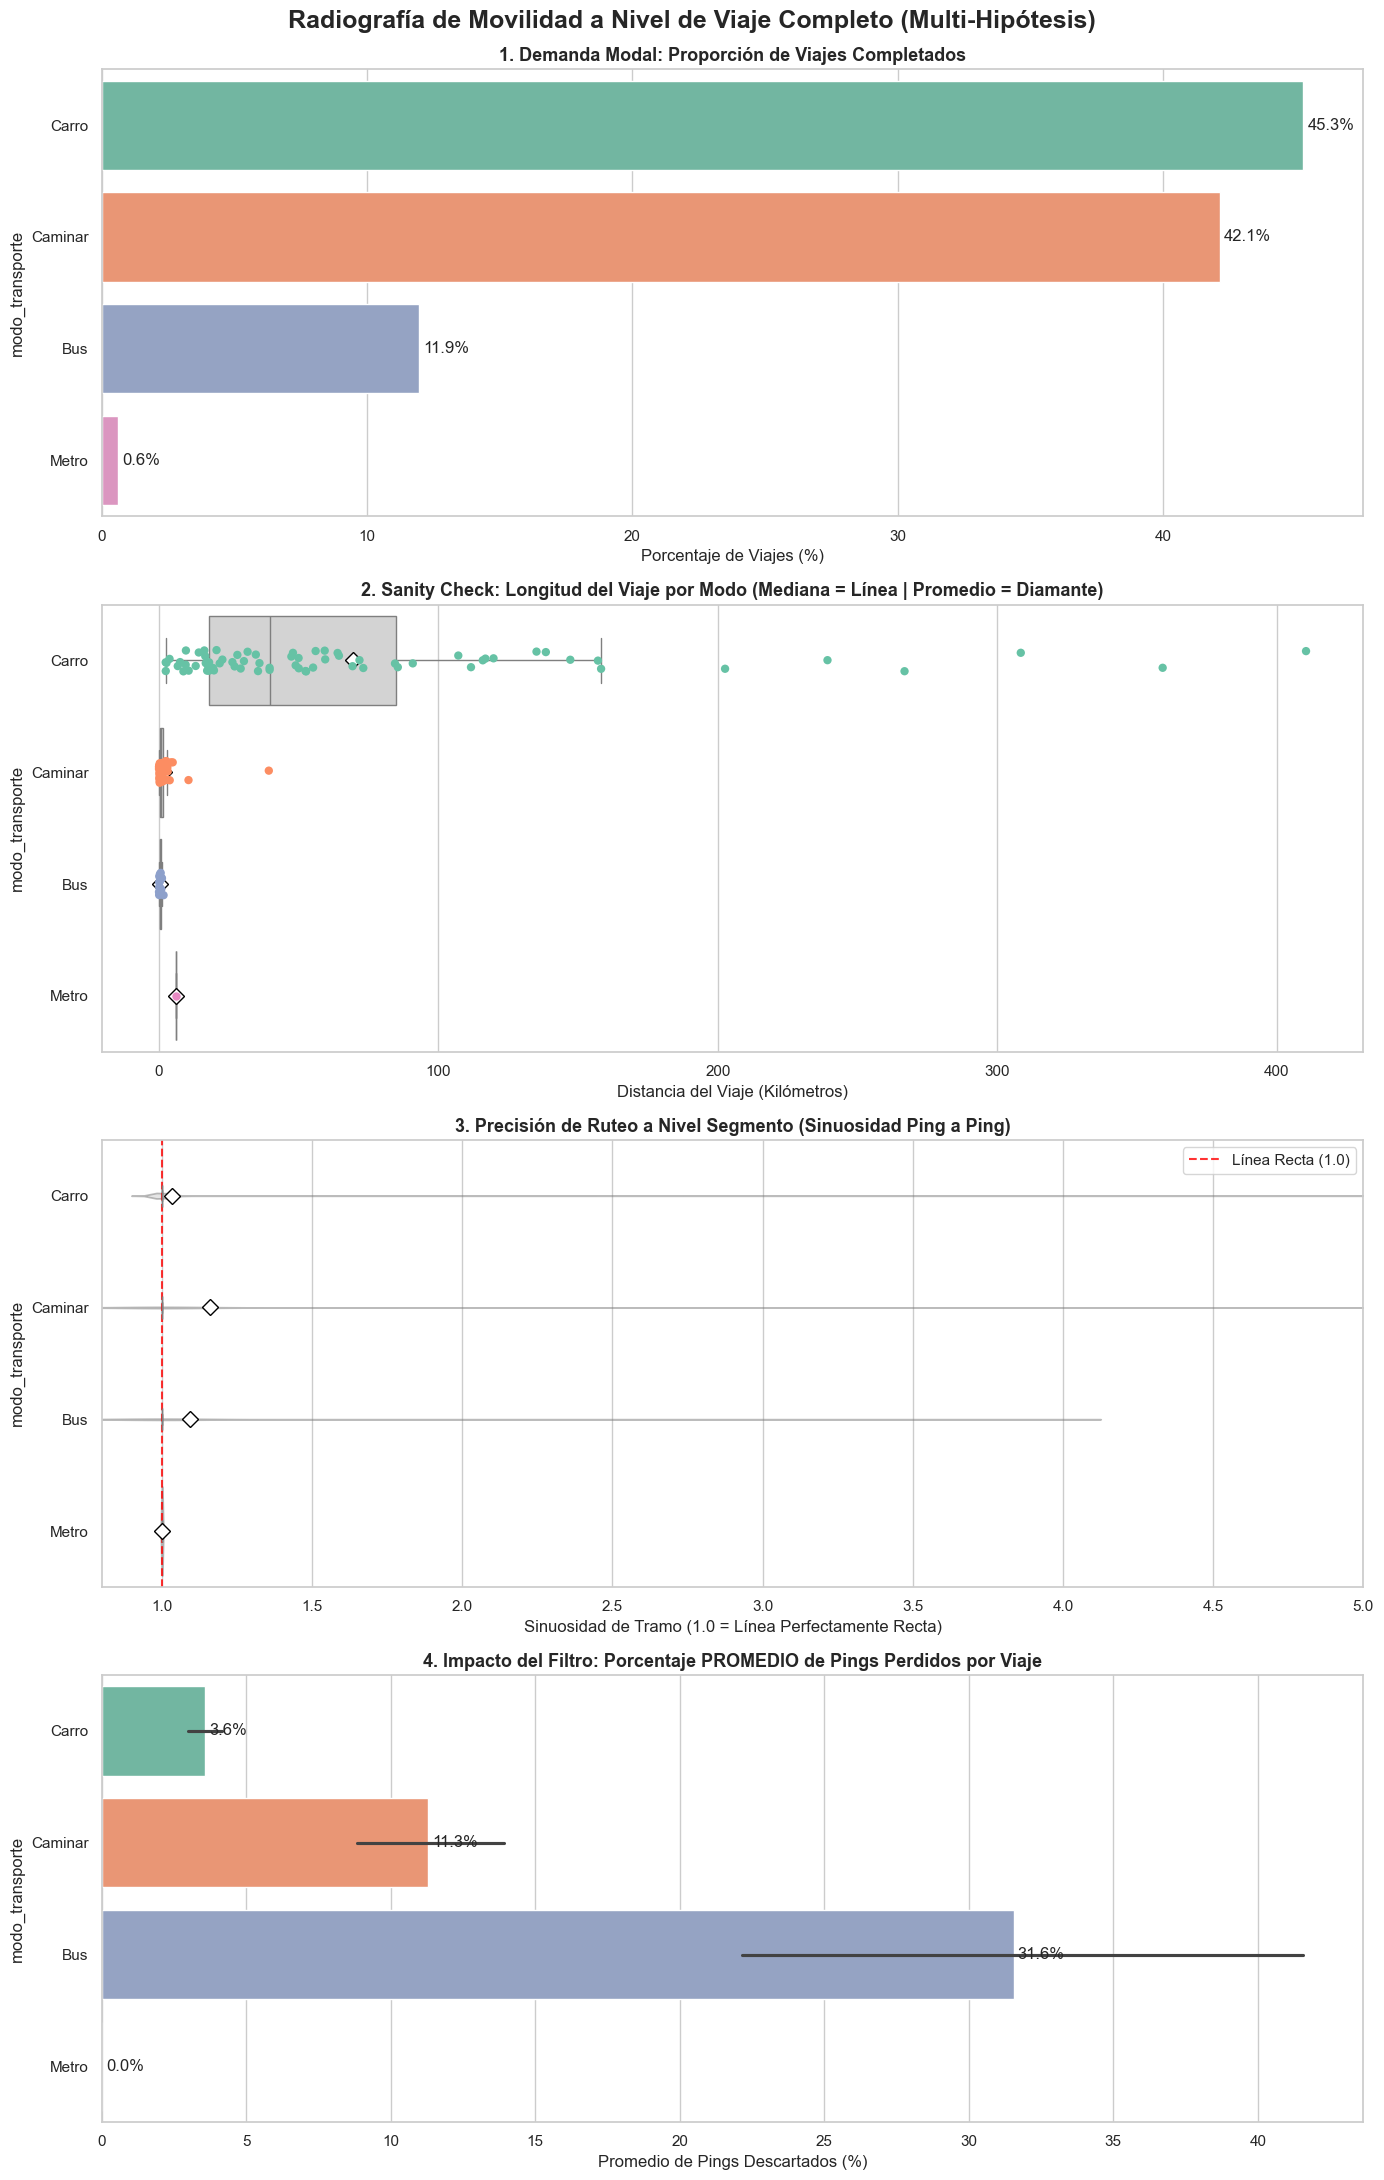

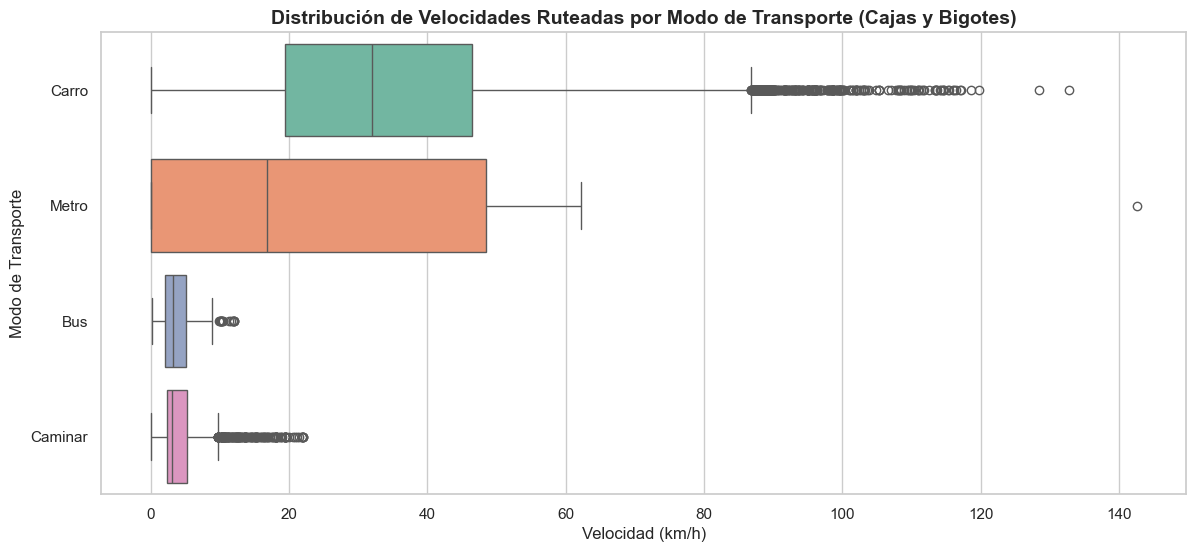

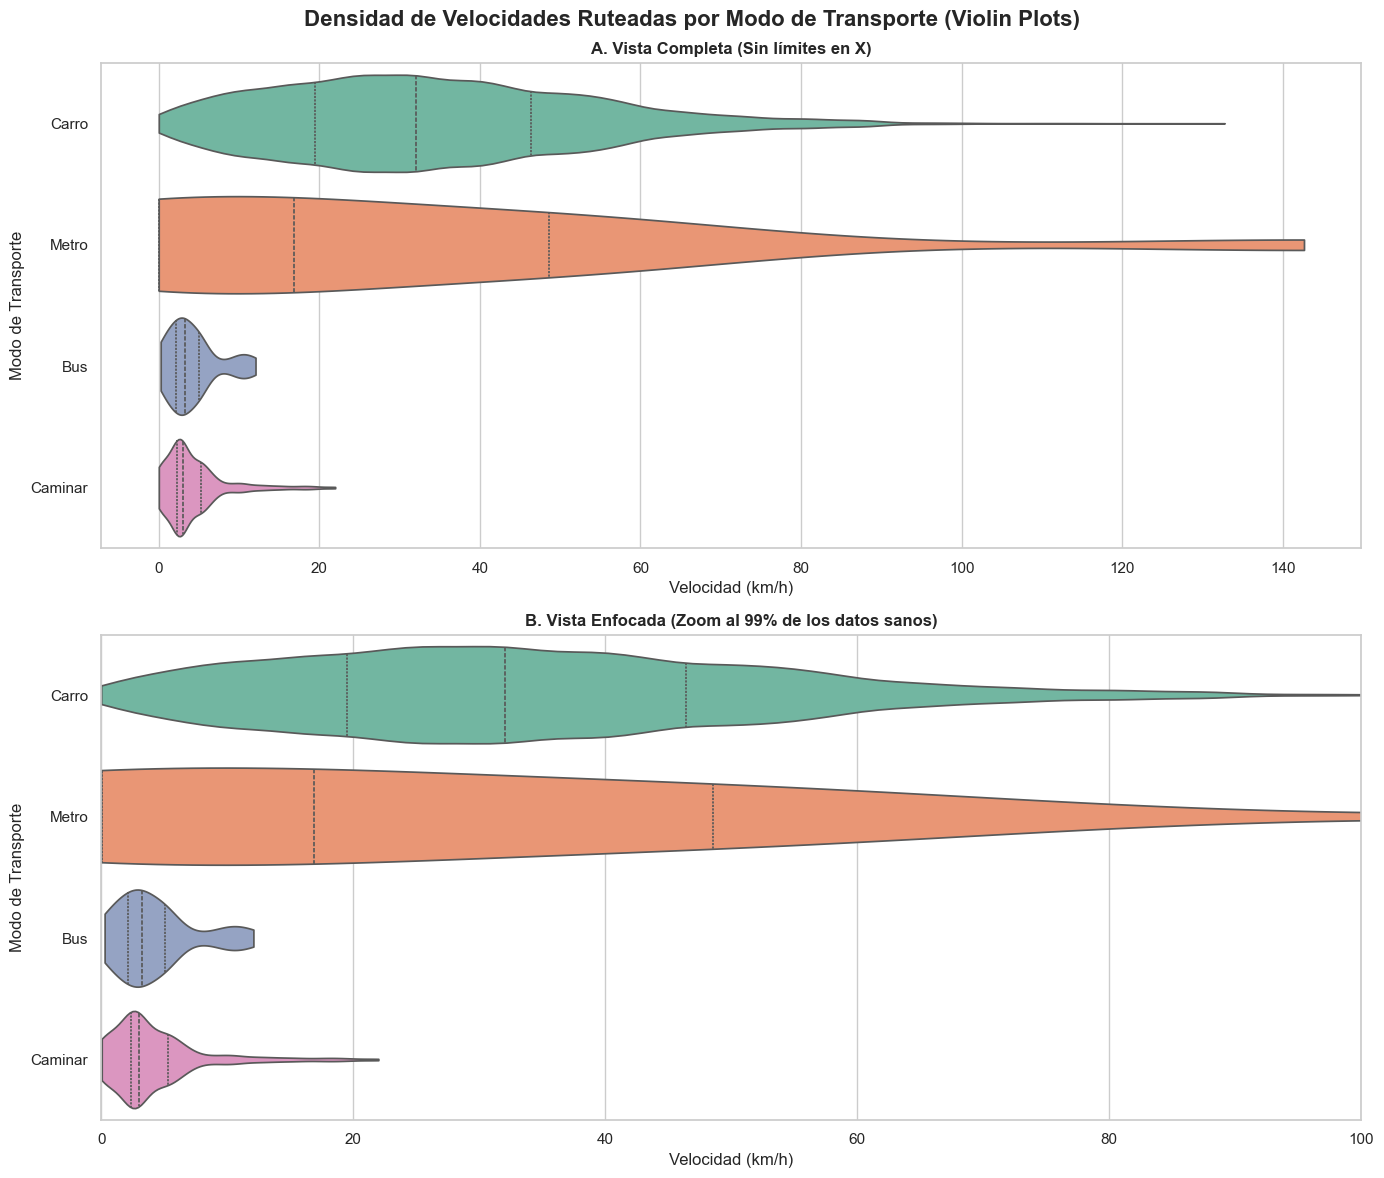

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1. Formula Haversine Vectorizada
def calc_haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371000.0  # Radio de la Tierra en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

# 2. Filtrar solo los datos en movimiento (excluir paradas)
df_viajes_pings = df_final[df_final['trip'] > 0].copy()

if df_viajes_pings.empty:
    print('No hay viajes en movimiento para analizar a nivel macro.')
else:
    df_viajes_pings['local_timestamp'] = pd.to_datetime(df_viajes_pings['local_timestamp'])
    df_viajes_pings = df_viajes_pings.sort_values(['caid', 'trip', 'local_timestamp'])
    siguiente_tiempo = df_viajes_pings.groupby(['caid', 'trip'])['local_timestamp'].shift(-1)
    df_viajes_pings['time_delta_s_real'] = (siguiente_tiempo - df_viajes_pings['local_timestamp']).dt.total_seconds().fillna(0)

    # 3. Agrupación (Separamos por Usuario, Viaje Y MODO DE TRANSPORTE)
    trip_stats = df_viajes_pings.groupby(['caid', 'trip', 'modo_transporte']).agg(
        distancia_total_m=('distance_m', 'sum'),
        tiempo_total_s=('time_delta_s_real', 'sum'), 
        total_pings=('caid', 'count'),
        pings_amnesia=('flag_auditoria', lambda x: x.str.contains('Amnesia|Lookahead', na=False).sum()), 
        lat_start=('latitude', 'first'),
        lon_start=('longitude', 'first'),
        lat_end=('latitude', 'last'),
        lon_end=('longitude', 'last')
    ).reset_index()

    # 4. Cálculo de Métricas Macro
    trip_stats['distancia_haversine_m'] = calc_haversine_vectorized(
        trip_stats['lat_start'], trip_stats['lon_start'], 
        trip_stats['lat_end'], trip_stats['lon_end']
    )
    trip_stats['distancia_total_km'] = trip_stats['distancia_total_m'] / 1000.0
    trip_stats['sinuosidad'] = np.where(
        trip_stats['distancia_haversine_m'] > 0,
        trip_stats['distancia_total_m'] / trip_stats['distancia_haversine_m'],
        1.0
    )
    trip_stats['tasa_amnesia_pct'] = (trip_stats['pings_amnesia'] / trip_stats['total_pings']) * 100

    trip_stats_clean = trip_stats[(trip_stats['distancia_total_m'] > 0) & (trip_stats['tiempo_total_s'] > 0)].copy()

    # --- Sinuosidad a nivel de segmento (ping a ping) ---
    df_viajes_pings['lat_next'] = df_viajes_pings.groupby(['caid', 'trip'])['latitude'].shift(-1)
    df_viajes_pings['lon_next'] = df_viajes_pings.groupby(['caid', 'trip'])['longitude'].shift(-1)
    df_segmentos = df_viajes_pings.dropna(subset=['lat_next', 'lon_next']).copy()
    df_segmentos['segment_haversine_m'] = calc_haversine_vectorized(
        df_segmentos['latitude'], df_segmentos['longitude'], 
        df_segmentos['lat_next'], df_segmentos['lon_next']
    )
    df_segmentos = df_segmentos[df_segmentos['segment_haversine_m'] >= 5.0].copy()
    df_segmentos['segment_sinuosity'] = df_segmentos['distance_m'] / df_segmentos['segment_haversine_m']
    df_segmentos_clean = df_segmentos[
        (df_segmentos['segment_sinuosity'] >= 0.95) & 
        (df_segmentos['segment_sinuosity'] <= 5.0)
    ].copy()

    print('='*70)
    print(f'AUDITORÍA DE VIAJES CONSOLIDADA: {len(trip_stats_clean):,} viajes únicos')
    print('='*70)

    if not trip_stats_clean.empty:
        fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 22))
        fig.suptitle('Radiografía de Movilidad a Nivel de Viaje Completo (Multi-Hipótesis)', fontsize=18, fontweight='bold', y=0.99)

        order_modos = trip_stats_clean['modo_transporte'].value_counts().index

        # --- Gráfico 1: Demanda Modal ---
        trip_counts_pct = trip_stats_clean['modo_transporte'].value_counts(normalize=True) * 100
        sns.barplot(x=trip_counts_pct.values, y=trip_counts_pct.index, ax=axes[0], palette='Set2', order=order_modos)
        axes[0].set_title('1. Demanda Modal: Proporción de Viajes Completados', fontweight='bold', fontsize=13)
        axes[0].set_xlabel('Porcentaje de Viajes (%)')
        for container in axes[0].containers:
            axes[0].bar_label(container, fmt='%.1f%%', padding=3)

        mean_marker_props = {"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}

        # --- Gráfico 2: Longitud del Viaje ---
        sns.boxplot(data=trip_stats_clean, y='modo_transporte', x='distancia_total_km', ax=axes[1], color='lightgray', showfliers=False, order=order_modos, showmeans=True, meanprops=mean_marker_props)
        sns.stripplot(data=trip_stats_clean, y='modo_transporte', x='distancia_total_km', ax=axes[1], palette='Set2', size=6, jitter=True, order=order_modos)
        axes[1].set_title('2. Sanity Check: Longitud del Viaje por Modo (Mediana = Línea | Promedio = Diamante)', fontweight='bold', fontsize=13)
        axes[1].set_xlabel('Distancia del Viaje (Kilómetros)')

        # --- Gráfico 3: Precisión de Ruteo a Nivel Segmento (Sinuosidad Ping a Ping) ---
        if not df_segmentos_clean.empty:
            sns.violinplot(data=df_segmentos_clean, y='modo_transporte', x='segment_sinuosity', ax=axes[2], inner=None, color=".8", order=order_modos, alpha=0.5)
            sns.boxplot(data=df_segmentos_clean, y='modo_transporte', x='segment_sinuosity', ax=axes[2], color='lightgray', width=0.2, showfliers=False, order=order_modos, showmeans=True, meanprops=mean_marker_props)
            axes[2].set_title('3. Precisión de Ruteo a Nivel Segmento (Sinuosidad Ping a Ping)', fontweight='bold', fontsize=13)
            axes[2].set_xlabel('Sinuosidad de Tramo (1.0 = Línea Perfectamente Recta)')
            axes[2].axvline(1.0, color='red', linestyle='--', alpha=0.8, label='Línea Recta (1.0)')
            axes[2].set_xlim(0.8, 5.0)
            axes[2].legend(loc='upper right')
        else:
            axes[2].set_title('3. Precisión de Ruteo a Nivel Segmento (Sinuosidad Ping a Ping - Sin Datos)', fontweight='bold', fontsize=13)

        # --- Gráfico 4: Tasa de Amnesia ---
        sns.barplot(data=trip_stats_clean, y='modo_transporte', x='tasa_amnesia_pct', estimator=np.mean, ax=axes[3], palette='Set2', order=order_modos)
        axes[3].set_title('4. Impacto del Filtro: Porcentaje PROMEDIO de Pings Perdidos por Viaje', fontweight='bold', fontsize=13)
        axes[3].set_xlabel('Promedio de Pings Descartados (%)')
        for container in axes[3].containers:
            axes[3].bar_label(container, fmt='%.1f%%', padding=3)

        plt.tight_layout()
        plt.show()

        # --- Gráficos de Velocidad a Nivel de Pings ---
        df_plot_speed = df_final[(df_final['Speed [km/h]'] > 0) & (df_final['Speed [km/h]'] <= 150)]
        if not df_plot_speed.empty:
            # Boxplot de Velocidades
            fig_sp, ax_sp = plt.subplots(figsize=(14, 6))
            order_speed = df_plot_speed.groupby('modo_transporte')['Speed [km/h]'].median().sort_values(ascending=False).index
            sns.boxplot(data=df_plot_speed, y='modo_transporte', x='Speed [km/h]', ax=ax_sp, palette='Set2', order=order_speed)
            ax_sp.set_title('Distribución de Velocidades Ruteadas por Modo de Transporte (Cajas y Bigotes)', fontweight='bold', fontsize=14)
            ax_sp.set_xlabel('Velocidad (km/h)')
            ax_sp.set_ylabel('Modo de Transporte')
            plt.show()
            
            # Violines de Velocidades
            fig_v, axes_v = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))
            fig_v.suptitle('Densidad de Velocidades Ruteadas por Modo de Transporte (Violin Plots)', fontsize=16, fontweight='bold', y=0.98)
            
            sns.violinplot(data=df_plot_speed, y='modo_transporte', x='Speed [km/h]', ax=axes_v[0], palette='Set2', order=order_speed, inner='quartile', cut=0, scale='width')
            axes_v[0].set_title('A. Vista Completa (Sin límites en X)', fontweight='bold', fontsize=12)
            axes_v[0].set_xlabel('Velocidad (km/h)')
            axes_v[0].set_ylabel('Modo de Transporte')
            
            sns.violinplot(data=df_plot_speed, y='modo_transporte', x='Speed [km/h]', ax=axes_v[1], palette='Set2', order=order_speed, inner='quartile', cut=0, scale='width')
            axes_v[1].set_title('B. Vista Enfocada (Zoom al 99% de los datos sanos)', fontweight='bold', fontsize=12)
            axes_v[1].set_xlabel('Velocidad (km/h)')
            axes_v[1].set_ylabel('Modo de Transporte')
            
            limite_visual_violin = df_plot_speed['Speed [km/h]'].quantile(0.99)
            if pd.isna(limite_visual_violin) or limite_visual_violin == 0:
                limite_visual_violin = 100
            axes_v[1].set_xlim(0, max(100, limite_visual_violin))
            
            plt.tight_layout()
            plt.show()


In [9]:
print('='*60)
print('REPORTE DE DIAGNÓSTICO DETALLADO: MÓDULO 3 EMISIONES')
print('='*60)

resumen_source = df_final.groupby('Source').agg(
    Registros=('Source', 'size'),
    Distancia_km=('distance_m', lambda x: x.sum() / 1000.0)
)
total_regs = resumen_source['Registros'].sum()
total_dist = resumen_source['Distancia_km'].sum()

for source, row in resumen_source.iterrows():
    pct_reg = (row['Registros'] / total_regs) * 100
    pct_dist = (row['Distancia_km'] / total_dist) * 100 if total_dist > 0 else 0
    nombre = 'No Motorizado/Parada' if source == 0 else ('Carro' if source == 21 else 'Bus')
    print(f'   - {nombre} (ID {source}): {row["Registros"]:,} registros ({pct_reg:.2f}%) | {row["Distancia_km"]:,.2f} km ({pct_dist:.2f}%)')

POLLUTANTS_noeqiv = ['CO', 'CO2', 'HC', 'NOx', 'PM10', 'PM25']

print('\n▶ 2. Inventario Total de Contaminantes (Global):')
totales_emisiones = {p: df_final[f'Total_{p}_g'].sum() for p in POLLUTANTS_noeqiv} 
serie_totales = pd.Series(totales_emisiones).sort_values(ascending=False)
total_masa = serie_totales.sum()

for p, masa in serie_totales.items():
    pct = (masa / total_masa) * 100 if total_masa > 0 else 0
    print(f'   - {p}: {masa:,.2f} g ({pct:.4f}%)')

print('\n▶ 3. Inventario Local de Calidad del Aire (EXCLUYENDO CO2):')
pol_excluidos = [p for p in POLLUTANTS_noeqiv if p != 'CO2']
totales_sin_co2 = {p: df_final[f'Total_{p}_g'].sum() for p in pol_excluidos}
serie_sin_co2 = pd.Series(totales_sin_co2).sort_values(ascending=False)
total_masa_sin_co2 = serie_sin_co2.sum()

for p, masa in serie_sin_co2.items():
    pct = (masa / total_masa_sin_co2) * 100 if total_masa_sin_co2 > 0 else 0
    print(f'   - {p}: {masa:,.2f} g ({pct:.2f}%)')

print('\n▶ 4. Calidad del Cruce con MOVES (Efectividad del Modelo):')
motorizados = df_final[df_final['Source'] > 0]
total_motorizados = len(motorizados)
fallos = len(motorizados[(motorizados['Densidad_CO2_g_km'] == 0) & (motorizados['distance_m'] > 0)]) if total_motorizados > 0 else 0
segmentos_cero_dist = motorizados[motorizados['distance_m'] == 0]

if total_motorizados > 0:
    tasa_exito = ((total_motorizados - fallos) / total_motorizados) * 100
    print(f'   - Registros motorizados procesados: {total_motorizados:,}')
    print(f'   - Registros con factor de emisión asignado: {total_motorizados - fallos:,}')
    print(f'   - TASA DE ÉXITO DE MAPEO: {tasa_exito:.2f} %')
    if fallos > 0:
        print(f'   - Registros huérfanos (sin match en MOVES): {fallos:,} ({(fallos/total_motorizados)*100:.2f}%)')
else:
    print('   - No hay registros motorizados para evaluar.')

print(f'\n   Nota: Hay {len(segmentos_cero_dist):,} segmentos motorizados donde la distancia avanzada fue 0 metros.')
print("="*60)


REPORTE DE DIAGNÓSTICO DETALLADO: MÓDULO 3 EMISIONES
   - No Motorizado/Parada (ID 0): 29,510.0 registros (35.23%) | 127.17 km (2.48%)
   - Carro (ID 21): 53,762.0 registros (64.19%) | 4,987.45 km (97.35%)
   - Bus (ID 42): 483.0 registros (0.58%) | 8.66 km (0.17%)

▶ 2. Inventario Total de Contaminantes (Global):
   - CO2: 1,711,502.99 g (95.9286%)
   - CO: 61,294.72 g (3.4355%)
   - NOx: 9,796.37 g (0.5491%)
   - HC: 1,166.67 g (0.0654%)
   - PM10: 203.22 g (0.0114%)
   - PM25: 179.33 g (0.0101%)

▶ 3. Inventario Local de Calidad del Aire (EXCLUYENDO CO2):
   - CO: 61,294.72 g (84.38%)
   - NOx: 9,796.37 g (13.49%)
   - HC: 1,166.67 g (1.61%)
   - PM10: 203.22 g (0.28%)
   - PM25: 179.33 g (0.25%)

▶ 4. Calidad del Cruce con MOVES (Efectividad del Modelo):
   - Registros motorizados procesados: 54,245
   - Registros con factor de emisión asignado: 54,245
   - TASA DE ÉXITO DE MAPEO: 100.00 %

   Nota: Hay 4,898 segmentos motorizados donde la distancia avanzada fue 0 metros.
